(185, 21604)
[  100   381   641   901  1172  1442  1693  1943  2213  2494  2754  3004
  3264  3514  3784  4064  4345  4626  4971  5221  5501  5761  6022  6282
  6532  6877  7148  7398  7679  7939  8209  8459  8825  9085  9365  9625
  9906 10166 10446 10868 11128 11388 11723 11994 12339 12599 12849 13099
 13520 13770 14040 14406 14677 14937 15187 15447 15793 16213 16484 16829
 17175 17530 17867 18127 18407 18678 19023 19283 19649 19899 20179 20450
 20700 20981 21411]
(250, 10)
(250, 10)
(250, 10)
(250, 10)
(250, 10)
(250, 10)
(250, 10)
(250, 10)
(250, 10)
(250, 10)
(250, 10)
(250, 10)
(250, 10)
(250, 10)
(250, 10)
(250, 10)
(250, 10)
(250, 10)
(250, 10)
(250, 10)
(250, 10)
(250, 10)
(250, 10)
(250, 10)
(250, 10)
(250, 10)
(250, 10)
(250, 10)
(250, 10)
(250, 10)
(250, 10)
(250, 10)
(250, 10)
(250, 10)
(250, 10)
(250, 10)
(250, 10)
(250, 10)
(250, 10)
(250, 10)
(250, 10)
(250, 10)
(250, 10)
(250, 10)
(250, 10)
(250, 10)
(250, 10)
(250, 10)
(250, 10)
(250, 10)
(250, 10)
(250, 10)
(250, 10)

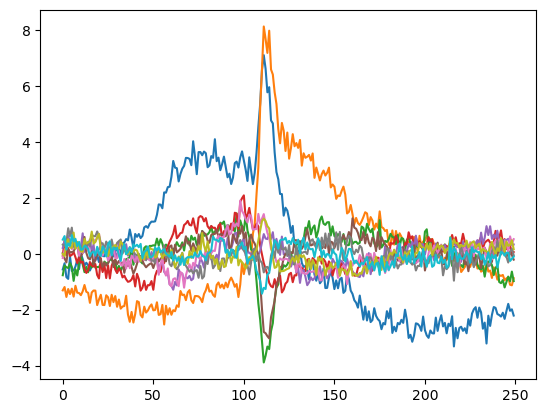

In [19]:
import numpy as np
import scipy.io
import scipy.stats
from sklearn import manifold



def generate_continuous_data(raw_data, event_times, trial_range, padding, delay=0.09):
    """
    Extract a continuous time window from z-scored neural data and
    compute event indices within that window.

    Parameters
    ----------
    raw_data : ndarray, shape (n_neurons, n_timepoints)
        Neural activity matrix.
    event_times : array-like
        Event time for each trial.
    trial_range : list or tuple
        [start_trial, end_trial] inclusive.
    padding : list or tuple
        [left_padding, right_padding] in time bins.
    delay : float
        Small trial-to-trial offset added to event indices to account
        for temporal delay across trials.

    Returns
    -------
    data : ndarray
        Continuous data window.
    event_index : ndarray
        Event indices inside the extracted window.
    """
    # Z-score each neuron across time
    zs_data = scipy.stats.zscore(raw_data, axis=1)

    start_trial, end_trial = trial_range
    left_pad, right_pad = padding

    # Extract one continuous chunk spanning the selected trials
    start_idx = round(event_times[start_trial]) - left_pad
    end_idx = round(event_times[end_trial]) + right_pad
    data = zs_data[:, start_idx:end_idx]

    # Compute event indices relative to the extracted chunk
    event_index = []
    for i in range(start_trial, end_trial + 1):
        idx = round(event_times[i]) - start_idx
        event_index.append(idx)

    event_index = np.array(event_index)

    event_index_new = []
    for i, e in enumerate(event_index):
        event_index_new.append(round(e + i * delay))

    event_index = np.array(event_index_new)

    return np.array(data), event_index


# --------------------------------------------------
# Load neural data
# --------------------------------------------------
path = "E:/CK-87-Data/2023-04-06/"

trace_data_file = path + "2023-04-06_matlab.mat"
trial_idx_file = path + "Trial_idx1.mat"

trace_data = scipy.io.loadmat(trace_data_file)
trial_idx = scipy.io.loadmat(trial_idx_file)

# Trial index and event times
trial_idx1 = trial_idx["Trial_idx1"]
door_open = trial_idx1[:, 1]

# Deconvolved activity
deconvolved_data = trace_data["s_diff"]

# --------------------------------------------------
# Build continuous dataset
# --------------------------------------------------
continuous_data, door_open_index = generate_continuous_data(
    deconvolved_data,
    door_open,
    trial_range=[0, len(door_open) - 1],
    padding=[100, 200]
)

# --------------------------------------------------
# Run Isomap
# --------------------------------------------------
print(continuous_data.shape)
reducer = manifold.Isomap(n_neighbors=200,n_components=10,metric='euclidean')
embeddings = reducer.fit_transform(continuous_data.T)
print(door_open_index)
all_trial_embeddings = []
for e in door_open_index[:]:
    single_trial_embeddings = embeddings[e-100:e+150,:]
    print(single_trial_embeddings.shape)
    all_trial_embeddings.append(single_trial_embeddings)
all_trial_embeddings = np.array(all_trial_embeddings)
trial_averaged_embeddings = np.mean(all_trial_embeddings,axis=0)
plt.plot(trial_averaged_embeddings)

# Option
# scipy.io.savemat(path+'Isomap.mat',{'trial_averaged_embeddings':trial_averaged_embeddings,
#                                    'all_trial_embeddings':all_trial_embeddings,
#                                    'embeddings':embeddings,
#                                    'door_open_index':door_open_index})